# E-Commerce Sales and Customer Experience Analysis

This notebook analyzes revenue, product, geographic, and customer-experience
performance for a configurable analysis period, benchmarked against a
comparison period.

## Table of Contents

1. [Introduction and Business Objectives](#1.-Introduction-and-Business-Objectives)
2. [Data Dictionary](#2.-Data-Dictionary)
3. [Data Loading and Configuration](#3.-Data-Loading-and-Configuration)
4. [Data Preparation and Transformation](#4.-Data-Preparation-and-Transformation)
5. [Business Metrics Calculation](#5.-Business-Metrics-Calculation)
   1. [Revenue Analysis](#5.1-Revenue-Analysis)
   2. [Product Category Analysis](#5.2-Product-Category-Analysis)
   3. [Geographic Analysis](#5.3-Geographic-Analysis)
   4. [Customer Experience Analysis](#5.4-Customer-Experience-Analysis)
6. [Summary of Observations](#6.-Summary-of-Observations)

## 1. Introduction and Business Objectives

This analysis answers a recurring set of questions about the e-commerce
business for a given period:

- How much revenue did we generate, and how does it compare to a prior
  period?
- What is the revenue trend across the months of the period?
- What is the average order value, and how many orders were placed?
- Which product categories and which states generate the most revenue?
- How reliable is delivery, and how does delivery speed relate to customer
  review scores?

The period being analyzed and the period it is compared against are both
configurable in [Section 3](#3.-Data-Loading-and-Configuration), so the same
notebook can be re-run for any year or any single month without changing any
other cell.

## 2. Data Dictionary

The analysis draws on five source tables in `ecommerce_data/`.

**orders** (`orders_dataset.csv`) -- one row per order

| Column | Description |
|---|---|
| `order_id` | Unique order identifier |
| `customer_id` | Foreign key to `customers` |
| `order_status` | One of: `delivered`, `shipped`, `canceled`, `processing`, `pending`, `returned` |
| `order_purchase_timestamp` | When the order was placed |
| `order_approved_at` | When payment was approved |
| `order_delivered_carrier_date` | When the order was handed to the carrier |
| `order_delivered_customer_date` | When the order reached the customer (missing if not yet delivered) |
| `order_estimated_delivery_date` | Estimated delivery date shown to the customer at purchase time |

**order_items** (`order_items_dataset.csv`) -- one row per line item within an order

| Column | Description |
|---|---|
| `order_id` | Foreign key to `orders` |
| `order_item_id` | Line-item number within the order |
| `product_id` | Foreign key to `products` |
| `seller_id` | Foreign key identifying the selling merchant |
| `shipping_limit_date` | Latest date the seller should hand the item to the carrier |
| `price` | Line-item price, USD |
| `freight_value` | Shipping cost for the line item, USD |

**products** (`products_dataset.csv`) -- one row per product

| Column | Description |
|---|---|
| `product_id` | Unique product identifier |
| `product_category_name` | Product category |
| `product_name_length`, `product_description_length` | Character counts of the listing name / description |
| `product_photos_qty` | Number of listing photos |
| `product_weight_g`, `product_length_cm`, `product_height_cm`, `product_width_cm` | Physical dimensions |

**customers** (`customers_dataset.csv`) -- one row per order-customer relationship

| Column | Description |
|---|---|
| `customer_id` | Identifier scoped to a single order (a repeat shopper gets a new `customer_id` per order) |
| `customer_unique_id` | Stable identifier for the underlying shopper across orders |
| `customer_zip_code_prefix` | First digits of the shopper's postal code |
| `customer_city`, `customer_state` | Shopper's city and state |

**order_reviews** (`order_reviews_dataset.csv`) -- one row per review

| Column | Description |
|---|---|
| `review_id` | Unique review identifier |
| `order_id` | Foreign key to `orders` |
| `review_score` | Star rating, 1-5 |
| `review_comment_title`, `review_comment_message` | Free-text review content |
| `review_creation_date` | When the review was submitted |
| `review_answer_timestamp` | When the seller/platform responded |

**Business terms used throughout this notebook**

- **Revenue**: sum of order line-item `price` (excludes freight/shipping).
- **Delivered order**: an order whose `order_status` is `delivered`.
- **Average Order Value (AOV)**: line-item prices summed per order, then
  averaged across orders.
- **Delivery speed**: days between `order_purchase_timestamp` and
  `order_delivered_customer_date`.

## 3. Data Loading and Configuration

All data loading and cleaning logic lives in `data_loader.py`; all metric
calculations live in `business_metrics.py`. This notebook only orchestrates
those two modules and renders results.

The cell below is the single place that controls what this notebook
analyzes: the analysis period, the comparison period, and the delivery-speed
tiers used in the customer-experience section. Change these values and
re-run the notebook to analyze a different year, a single month, or
different delivery-speed tiers -- no other cell needs to change.

In [ ]:
import calendar

DATA_DIR = "ecommerce_data"

# Primary analysis period.
ANALYSIS_YEAR = 2023
ANALYSIS_MONTH = None  # 1-12 to scope to a single month; None means the full year

# Comparison period, used for all growth-rate metrics.
COMPARISON_YEAR = 2022
COMPARISON_MONTH = None

# Delivery-speed tiers used in the customer-experience section.
# DELIVERY_SPEED_BINS[i] is the inclusive upper bound (in days) of
# DELIVERY_SPEED_LABELS[i]; the final label catches everything above the
# last bin. Both lists must be configured together.
DELIVERY_SPEED_BINS = [3, 7]
DELIVERY_SPEED_LABELS = ["1-3 days", "4-7 days", "8+ days"]


def period_label(year, month=None):
    """Human-readable label for a year or a single year-month."""
    if month is None:
        return str(year)
    return f"{calendar.month_name[month]} {year}"


ANALYSIS_LABEL = period_label(ANALYSIS_YEAR, ANALYSIS_MONTH)
COMPARISON_LABEL = period_label(COMPARISON_YEAR, COMPARISON_MONTH)

print(f"Analysis period: {ANALYSIS_LABEL}")
print(f"Comparison period: {COMPARISON_LABEL}")

Analysis period: 2023
Comparison period: 2022


In [ ]:
import data_loader as dl
import business_metrics as bm

datasets = dl.load_datasets(DATA_DIR)
orders = dl.prepare_orders(datasets["orders"])
reviews = dl.prepare_reviews(datasets["reviews"])
products = datasets["products"]
customers = datasets["customers"]

print(f"Loaded {len(orders):,} orders, {len(datasets['order_items']):,} order items, "
      f"{len(products):,} products, {len(customers):,} customers, {len(reviews):,} reviews.")

Loaded 10,000 orders, 16,047 order items, 6,000 products, 8,000 customers, 6,571 reviews.


## 4. Data Preparation and Transformation

This section builds the analysis-ready sales table: order line items merged
with order status and dates, restricted to delivered orders, scoped to the
analysis and comparison periods defined above, and enriched with delivery
speed and review scores.

In [ ]:
sales = dl.build_sales_dataset(datasets["order_items"], orders)
sales_delivered = dl.filter_delivered(sales)

print(f"{len(sales):,} order line items across all order statuses.")
print(f"{len(sales_delivered):,} order line items with status 'delivered'.")

16,047 order line items across all order statuses.
15,095 order line items with status 'delivered'.


In [ ]:
sales_analysis = dl.filter_by_year_month(sales_delivered, year=ANALYSIS_YEAR, month=ANALYSIS_MONTH)
sales_comparison = dl.filter_by_year_month(sales_delivered, year=COMPARISON_YEAR, month=COMPARISON_MONTH)
orders_analysis = dl.filter_by_year_month(orders, year=ANALYSIS_YEAR, month=ANALYSIS_MONTH)

print(f"Analysis period ({ANALYSIS_LABEL}): {len(sales_analysis):,} delivered line items.")
print(f"Comparison period ({COMPARISON_LABEL}): {len(sales_comparison):,} delivered line items.")

Analysis period (2023): 7,448 delivered line items.
Comparison period (2022): 7,641 delivered line items.


In [ ]:
sales_analysis = dl.add_delivery_speed(sales_analysis)
sales_analysis_reviewed = dl.attach_reviews(sales_analysis, reviews)

print(f"{sales_analysis_reviewed['order_id'].nunique():,} distinct orders in the analysis "
      f"period ({ANALYSIS_LABEL}) have a matching review.")

3,225 distinct orders in the analysis period (2023) have a matching review.


## 5. Business Metrics Calculation

Every metric below is computed by `business_metrics.py` from the tables
prepared in Section 4. Charts use a single consistent blue color scheme
throughout, so color always means "this metric," never a different series
per category.

In [ ]:
import matplotlib.pyplot as plt
import plotly.express as px

# Business-oriented color scheme: one blue hue used consistently across
# every chart, plus a light-to-dark ramp for magnitude on the choropleth.
BLUE = "#2a78d6"
GRID_COLOR = "#e1e0d9"
INK = "#0b0b0b"
MUTED_INK = "#52514e"
BLUE_SEQUENTIAL = [
    "#cde2fb", "#b7d3f6", "#9ec5f4", "#86b6ef", "#6da7ec", "#5598e7",
    "#3987e5", "#2a78d6", "#256abf", "#1c5cab", "#184f95", "#104281", "#0d366b",
]


def style_axis(ax, title, xlabel, ylabel, grid_axis="y"):
    """Apply consistent title, axis-label, spine, and grid styling."""
    ax.set_title(title, fontsize=13, color=INK, pad=12)
    ax.set_xlabel(xlabel, fontsize=10, color=MUTED_INK)
    ax.set_ylabel(ylabel, fontsize=10, color=MUTED_INK)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis=grid_axis, color=GRID_COLOR, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    return ax

### 5.1 Revenue Analysis

Total revenue, its month-over-month trend across the analysis period, average
order value, and order count -- each compared against the comparison
period.

In [ ]:
current_revenue = bm.total_revenue(sales_analysis)
comparison_revenue = bm.total_revenue(sales_comparison)
revenue_growth = bm.revenue_growth_rate(sales_analysis, sales_comparison)

print(f"Total revenue ({ANALYSIS_LABEL}): ${current_revenue:,.2f}")
print(f"Total revenue ({COMPARISON_LABEL}): ${comparison_revenue:,.2f}")
print(f"Revenue growth vs {COMPARISON_LABEL}: {revenue_growth * 100:+.2f}%")

Total revenue (2023): $3,360,294.74
Total revenue (2022): $3,445,076.96
Revenue growth vs 2022: -2.46%


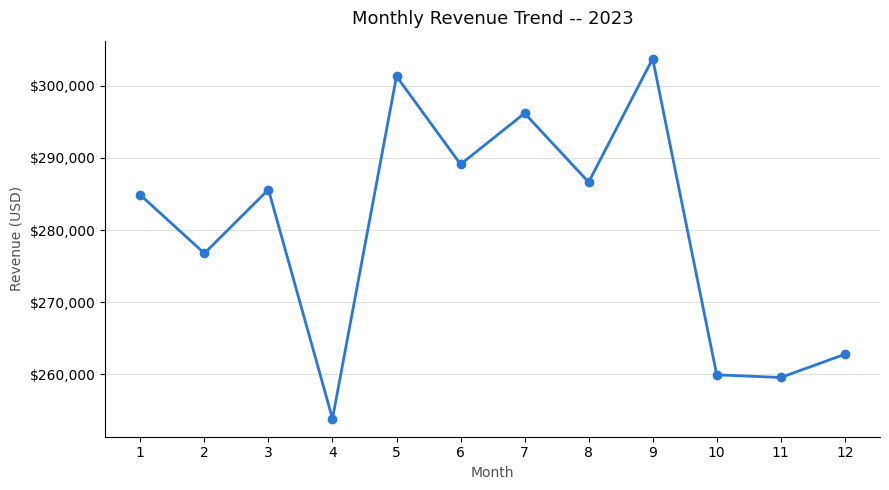

Average month-over-month revenue growth in 2023: -0.39%


In [ ]:
monthly_revenue = bm.monthly_revenue_trend(sales_analysis)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(monthly_revenue.index, monthly_revenue.values, marker="o", color=BLUE, linewidth=2)
style_axis(
    ax,
    title=f"Monthly Revenue Trend -- {ANALYSIS_LABEL}",
    xlabel="Month",
    ylabel="Revenue (USD)",
)
ax.set_xticks(monthly_revenue.index)
ax.yaxis.set_major_formatter(lambda value, _: f"${value:,.0f}")
plt.tight_layout()
plt.show()

if len(monthly_revenue) > 1:
    mom_growth = bm.average_month_over_month_growth(monthly_revenue)
    print(f"Average month-over-month revenue growth in {ANALYSIS_LABEL}: {mom_growth * 100:+.2f}%")
else:
    mom_growth = None
    print(f"{ANALYSIS_LABEL} covers a single month, so no month-over-month trend applies.")

In [ ]:
current_aov = bm.average_order_value(sales_analysis)
comparison_aov = bm.average_order_value(sales_comparison)
aov_growth = bm.order_value_growth_rate(sales_analysis, sales_comparison)

print(f"Average order value ({ANALYSIS_LABEL}): ${current_aov:,.2f}")
print(f"Average order value ({COMPARISON_LABEL}): ${comparison_aov:,.2f}")
print(f"Average order value growth vs {COMPARISON_LABEL}: {aov_growth * 100:+.2f}%")

Average order value (2023): $724.98
Average order value (2022): $725.43
Average order value growth vs 2022: -0.06%


In [ ]:
current_orders = bm.total_orders(sales_analysis)
comparison_orders = bm.total_orders(sales_comparison)
order_growth = bm.order_count_growth_rate(sales_analysis, sales_comparison)

print(f"Total orders ({ANALYSIS_LABEL}): {current_orders:,}")
print(f"Total orders ({COMPARISON_LABEL}): {comparison_orders:,}")
print(f"Order count growth vs {COMPARISON_LABEL}: {order_growth * 100:+.2f}%")

Total orders (2023): 4,635
Total orders (2022): 4,749
Order count growth vs 2022: -2.40%


### 5.2 Product Category Analysis

Revenue broken down by product category for the analysis period.

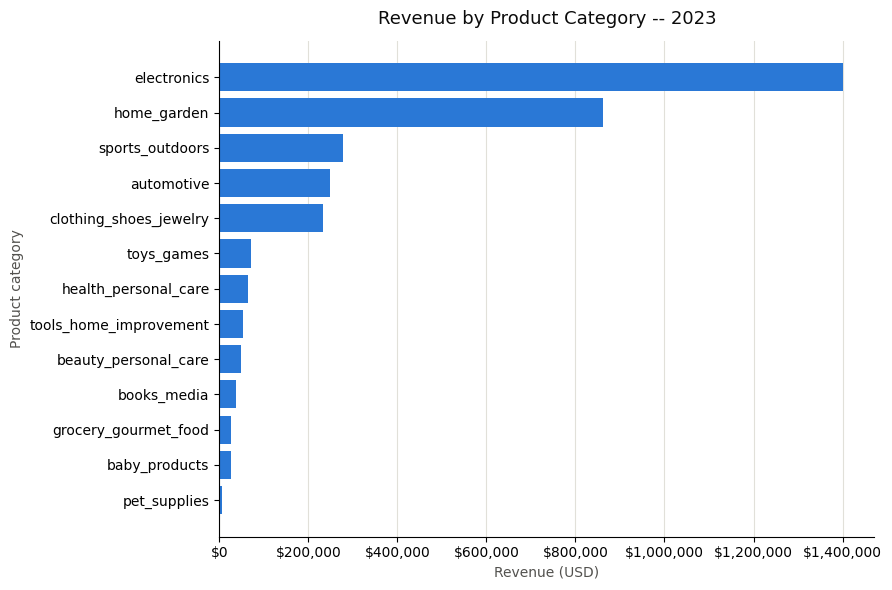

Top category by revenue in 2023: electronics ($1,401,359.21)


In [ ]:
category_revenue = bm.revenue_by_category(sales_analysis, products)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(category_revenue.index[::-1], category_revenue.values[::-1], color=BLUE)
style_axis(
    ax,
    title=f"Revenue by Product Category -- {ANALYSIS_LABEL}",
    xlabel="Revenue (USD)",
    ylabel="Product category",
    grid_axis="x",
)
ax.xaxis.set_major_formatter(lambda value, _: f"${value:,.0f}")
plt.tight_layout()
plt.show()

print(f"Top category by revenue in {ANALYSIS_LABEL}: "
      f"{category_revenue.index[0]} (${category_revenue.iloc[0]:,.2f})")

### 5.3 Geographic Analysis

Revenue broken down by customer state for the analysis period.

In [ ]:
state_revenue = bm.revenue_by_state(sales_analysis, orders, customers)

fig = px.choropleth(
    state_revenue,
    locations="customer_state",
    color="price",
    locationmode="USA-states",
    scope="usa",
    title=f"Revenue by State -- {ANALYSIS_LABEL}",
    labels={"price": "Revenue (USD)", "customer_state": "State"},
    color_continuous_scale=BLUE_SEQUENTIAL,
)
fig.update_layout(margin=dict(l=0, r=0, t=40, b=0))
fig.show()

print(f"Top state by revenue in {ANALYSIS_LABEL}: "
      f"{state_revenue.iloc[0]['customer_state']} (${state_revenue.iloc[0]['price']:,.2f})")

Top state by revenue in 2023: CA ($537,880.74)


### 5.4 Customer Experience Analysis

Order status mix, delivery speed, and how delivery speed relates to review
scores, for the analysis period.

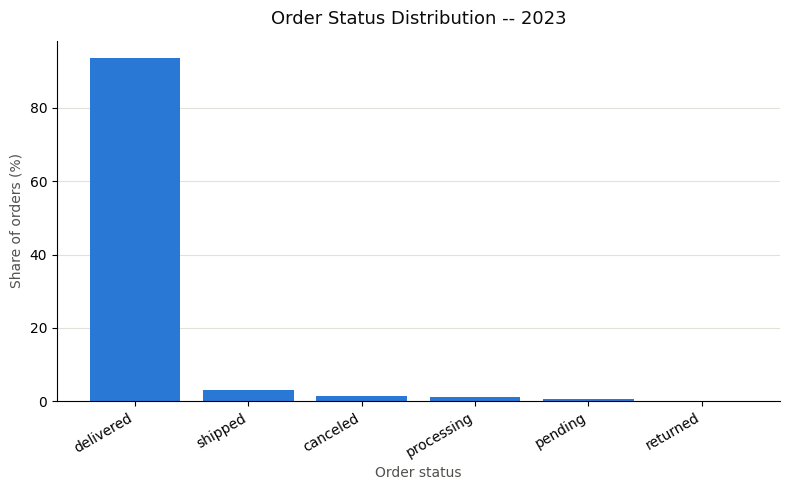

order_status
delivered     93.64
shipped        3.19
canceled       1.29
processing     1.19
pending        0.51
returned       0.18
Name: proportion, dtype: float64

In [ ]:
status_distribution = bm.order_status_distribution(orders_analysis)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(status_distribution.index, status_distribution.values * 100, color=BLUE)
style_axis(
    ax,
    title=f"Order Status Distribution -- {ANALYSIS_LABEL}",
    xlabel="Order status",
    ylabel="Share of orders (%)",
)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

status_distribution.mul(100).round(2)

Average delivery time in 2023: 8.01 days


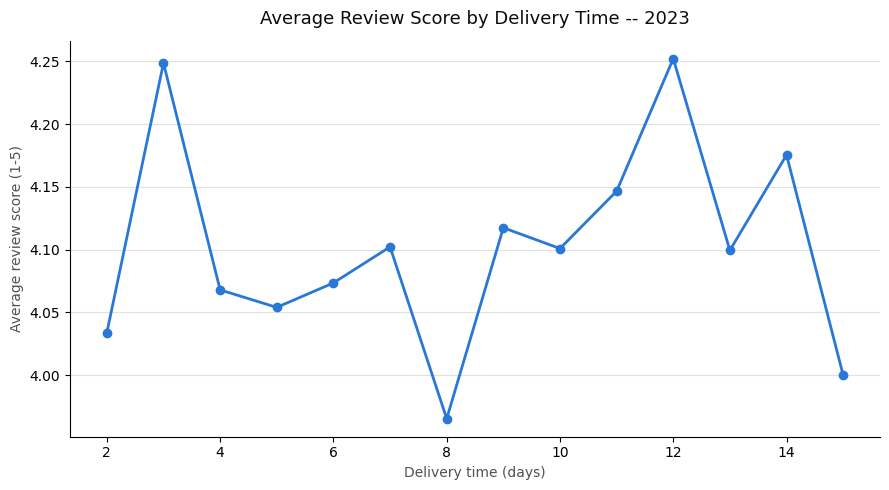

In [ ]:
avg_delivery_days = bm.average_delivery_time(sales_analysis_reviewed)
print(f"Average delivery time in {ANALYSIS_LABEL}: {avg_delivery_days:.2f} days")

review_by_days = bm.review_score_by_delivery_speed(sales_analysis_reviewed)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(review_by_days["delivery_speed_days"], review_by_days["review_score"],
        marker="o", color=BLUE, linewidth=2)
style_axis(
    ax,
    title=f"Average Review Score by Delivery Time -- {ANALYSIS_LABEL}",
    xlabel="Delivery time (days)",
    ylabel="Average review score (1-5)",
)
plt.tight_layout()
plt.show()

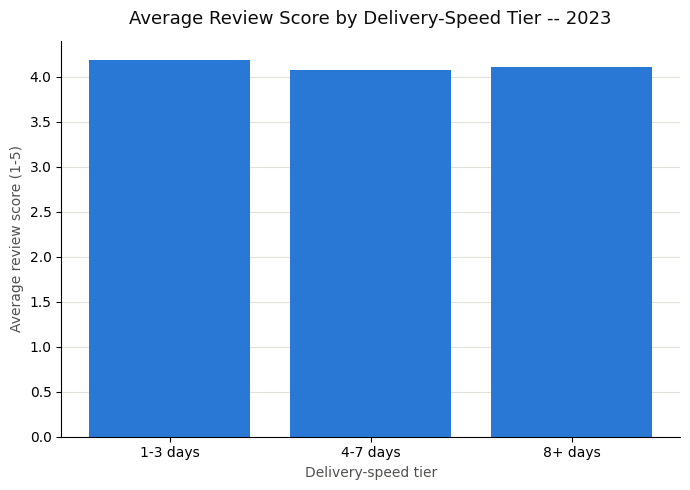

,delivery_tier,review_score
0,1-3 days,4.193966
1,4-7 days,4.075063
2,8+ days,4.108138


In [ ]:
review_by_tier = bm.review_score_by_delivery_tier(
    sales_analysis_reviewed, DELIVERY_SPEED_BINS, DELIVERY_SPEED_LABELS
)

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(review_by_tier["delivery_tier"], review_by_tier["review_score"], color=BLUE)
style_axis(
    ax,
    title=f"Average Review Score by Delivery-Speed Tier -- {ANALYSIS_LABEL}",
    xlabel="Delivery-speed tier",
    ylabel="Average review score (1-5)",
)
plt.tight_layout()
plt.show()

review_by_tier

Average review score in 2023: 4.10 / 5


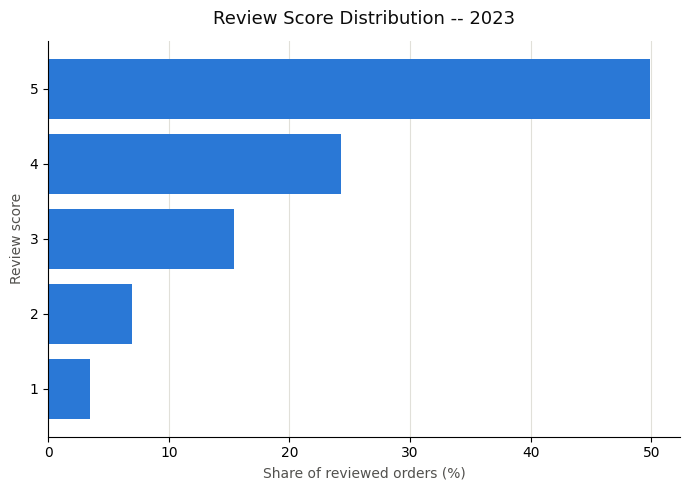

In [ ]:
avg_review = bm.average_review_score(sales_analysis_reviewed)
print(f"Average review score in {ANALYSIS_LABEL}: {avg_review:.2f} / 5")

review_dist = bm.review_score_distribution(sales_analysis_reviewed)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(review_dist.index.astype(str), review_dist.values * 100, color=BLUE)
style_axis(
    ax,
    title=f"Review Score Distribution -- {ANALYSIS_LABEL}",
    xlabel="Share of reviewed orders (%)",
    ylabel="Review score",
    grid_axis="x",
)
plt.tight_layout()
plt.show()

## 6. Summary of Observations

In [ ]:
mom_growth_display = "n/a (single month)" if mom_growth is None else f"{mom_growth * 100:+.2f}%"

print(f"Summary for {ANALYSIS_LABEL} (vs {COMPARISON_LABEL})")
print("-" * 50)
print(f"Revenue: ${current_revenue:,.2f} ({revenue_growth * 100:+.2f}%)")
print(f"Orders: {current_orders:,} ({order_growth * 100:+.2f}%)")
print(f"Average order value: ${current_aov:,.2f} ({aov_growth * 100:+.2f}%)")
print(f"Average month-over-month revenue growth: {mom_growth_display}")
print(f"Top product category: {category_revenue.index[0]} (${category_revenue.iloc[0]:,.2f})")
print(f"Top state: {state_revenue.iloc[0]['customer_state']} (${state_revenue.iloc[0]['price']:,.2f})")
print(f"Average delivery time: {avg_delivery_days:.2f} days")
print(f"Average review score: {avg_review:.2f} / 5")

Summary for 2023 (vs 2022)
--------------------------------------------------
Revenue: $3,360,294.74 (-2.46%)
Orders: 4,635 (-2.40%)
Average order value: $724.98 (-0.06%)
Average month-over-month revenue growth: -0.39%
Top product category: electronics ($1,401,359.21)
Top state: CA ($537,880.74)
Average delivery time: 8.01 days
Average review score: 4.10 / 5


Based on the default configuration (analysis period 2023, comparison period
2022):

- Revenue declined 2.46% year over year while average order value was
  essentially flat (-0.06%), so the revenue decline tracks the 2.40% drop in
  order count rather than a change in per-order spending.
- Month-over-month revenue within 2023 was volatile (swings from about -14%
  to +19%) with a slightly negative average trend (-0.39% per month), rather
  than a steady directional trend.
- Revenue is concentrated in a small number of categories: electronics and
  home_garden together account for more than half of 2023 revenue, with the
  remaining eleven categories splitting the rest.
- Revenue is geographically concentrated as well, with California, Texas,
  and Florida the top three states.
- 93.6% of 2023 orders reached `delivered` status; the remainder are split
  across `shipped`, `canceled`, `processing`, `pending`, and `returned`.
- Average delivery time was 8.0 days. Average review score did not decline
  steadily with delivery time: the 1-3 day tier scored highest (4.19), the
  8+ day tier scored second (4.11), and the 4-7 day tier scored lowest
  (4.08) -- delivery speed alone does not fully explain review scores in
  this data.

These observations describe the default 2023-vs-2022 configuration; re-run
Section 3 with different `ANALYSIS_YEAR` / `ANALYSIS_MONTH` values to
regenerate this summary for a different period.